# 4. EV-GAN: a GAN designed for heavy tails

**Workshop time:** about 35–45 minutes.

This notebook compares a standard GAN with the **EV-GAN** construction of Allouche, Girard, and Gobet (2022), using a one-dimensional heavy-tailed Burr distribution.

The notation continues directly from the earlier notebooks:

- $X\in\mathbb{R}$ is the observed random variable;
- $Z\sim\pi$ is the latent variable;
- $G_\theta(Z)=\widetilde X$ is a generated observation;
- $D_\phi(x)$ discriminates real from generated observations.

For the baseline GAN and EV-GAN we use the same latent distribution,

$$
Z\sim U(0,1).
$$

The important difference is the **parametrisation of the generator**.

> **Source note.** The mathematical construction follows pp. 11–16 of the supplied EV-GAN slides. The implementation of the correction terms follows the authors' public PyTorch implementation of EV-GAN.

## Learning objectives

By the end of this notebook you should be able to:

1. explain why a standard ReLU GAN with bounded latent input struggles with an unbounded heavy-tailed distribution;
2. define the Tail-Index Function (TIF);
3. derive the inverse-TIF transformation used by EV-GAN;
4. construct an EV-GAN generator in PyTorch;
5. train a standard GAN and EV-GAN under the same adversarial loss;
6. compare their ability to reproduce extreme quantiles.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.special import expi

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.2.1
Device: mps


# 1. A heavy-tailed target distribution

The slides use Burr distributions to illustrate the difficulty faced by ordinary ReLU generators.

We parameterise a Burr XII distribution by the extreme-value parameters

$$
\gamma > 0,
\qquad
\rho < 0,
$$

using

$$
c=-\frac{\rho}{\gamma},
\qquad
d_B=-\frac{1}{\rho}.
$$

Its distribution function is

$$
F(x)=1-(1+x^c)^{-d_B},
\qquad x>0,
$$

and hence its quantile function is

$$
q(u)
=
\left\{(1-u)^{-1/d_B}-1\right\}^{1/c},
\qquad 0<u<1.
$$

We take

$$
\gamma=0.5,
\qquad
\rho=-1.
$$

Thus the distribution is  heavy tailed and its upper quantiles increase rapidly as $u\to1$.

In [3]:
gamma = 0.5
rho = -1.0

def burr_quantile(u, gamma=gamma, rho=rho):
    # Burr XII quantile in the (gamma, rho) parameterisation.
    u = np.asarray(u)
    c = -rho / gamma
    d_burr = -1.0 / rho
    return ((1.0 - u) ** (-1.0 / d_burr) - 1.0) ** (1.0 / c)

n = 6000
U_data = np.random.uniform(size=n)
X = burr_quantile(U_data).astype(np.float32).reshape(-1, 1)

print("Sample size:", n)
print("Sample median:", np.median(X))
print("Sample 0.99 quantile:", np.quantile(X, 0.99))
print("Sample maximum:", X.max())

Sample size: 6000
Sample median: 1.0036509
Sample 0.99 quantile: 9.330213537216192
Sample maximum: 39.991657


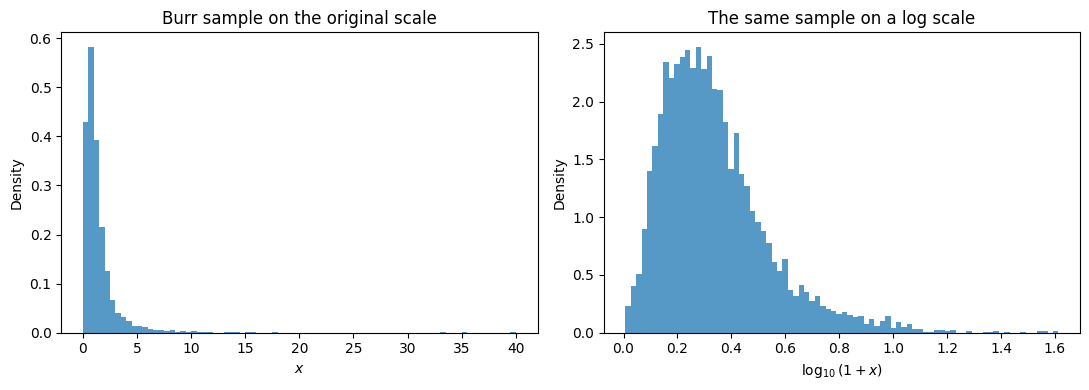

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(X.ravel(), bins=80, density=True, alpha=0.75)
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel("Density")
axes[0].set_title("Burr sample on the original scale")

axes[1].hist(np.log10(1 + X.ravel()), bins=80, density=True, alpha=0.75)
axes[1].set_xlabel(r"$\log_{10}(1+x)$")
axes[1].set_ylabel("Density")
axes[1].set_title("The same sample on a log scale")

plt.tight_layout()
plt.show()

# 2. Why the standard GAN has a structural tail problem

Suppose

$$
Z\sim U(0,1)
$$

and a standard generator $G_\theta$ is a finite ReLU network.

For fixed parameters $\theta$, $G_\theta$ is continuous. Since $[0,1]$ is compact,

$$
G_\theta([0,1])
$$

is bounded.

Therefore a standard generator with bounded latent input **cannot have an unbounded heavy tail**, regardless of how well it fits the centre of the observed distribution.

This is the issue EV-GAN is designed to address.

# 3. The Tail-Index Function

For a heavy-tailed distribution with quantile function $q$, the slides introduce

$$
f^{\mathrm{TIF}}(u)
=
-\frac{\log q(u)}
{\log\left(\frac{1-u^2}{2}\right)},
\qquad 0<u<1.
$$

Although

$$
q(u)\longrightarrow\infty
\qquad\text{as }u\to1,
$$

the Tail-Index Function remains bounded and satisfies

$$
f^{\mathrm{TIF}}(u)\longrightarrow\gamma
\qquad\text{as }u\to1.
$$

This is the key idea: **rather than asking a ReLU network to approximate an unbounded quantile function, ask it to approximate a bounded TIF.**

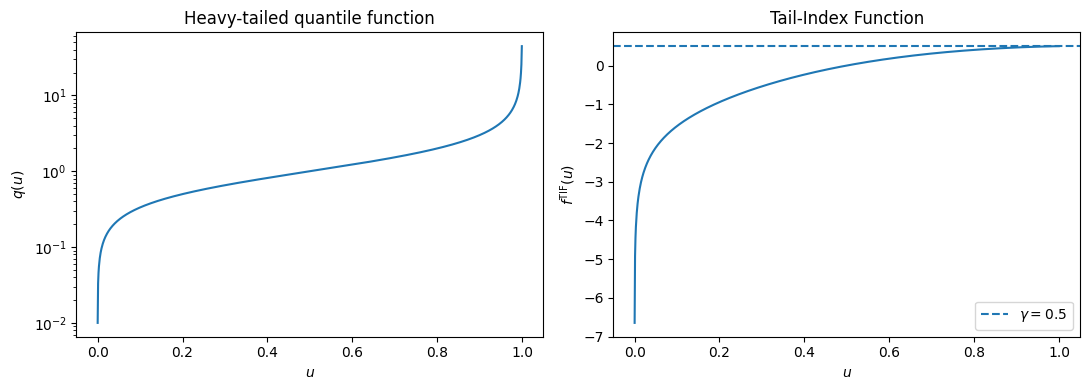

In [5]:
u_grid = np.linspace(1e-4, 0.9995, 1000)
q_true = burr_quantile(u_grid)

f_tif_true = (
    -np.log(q_true)
    / np.log((1.0 - u_grid**2) / 2.0)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(u_grid, q_true)
axes[0].set_xlabel(r"$u$")
axes[0].set_ylabel(r"$q(u)$")
axes[0].set_yscale("log")
axes[0].set_title("Heavy-tailed quantile function")

axes[1].plot(u_grid, f_tif_true)
axes[1].axhline(gamma, linestyle="--", label=rf"$\gamma={gamma}$")
axes[1].set_xlabel(r"$u$")
axes[1].set_ylabel(r"$f^{\mathrm{TIF}}(u)$")
axes[1].set_title("Tail-Index Function")
axes[1].legend()

plt.tight_layout()
plt.show()

# 4. Inverting the TIF

Rearranging the definition gives

$$
q(u)
=
\left(
\frac{1-u^2}{2}
\right)^{-f^{\mathrm{TIF}}(u)}.
$$

Define

$$
H_u^{-1}(x)
=
\left(
\frac{1-u^2}{2}
\right)^{-x}.
$$

EV-GAN therefore has the schematic form

$$
Z
\longrightarrow
\widehat f_\theta^{\mathrm{TIF}}(Z)
\longrightarrow
H_Z^{-1}\!\left(
\widehat f_\theta^{\mathrm{TIF}}(Z)
\right)
=
\widetilde X.
$$

The neural network only has to represent the bounded TIF-like quantity. The inverse-TIF transformation supplies the required unbounded tail behaviour.

In [6]:
class TIFInverse(nn.Module):
    # H_u^{-1}(x) = ((1-u^2)/2)^(-x)

    def forward(self, u, x):
        # Avoid evaluating exactly at the boundary u=1.
        u = u.clamp(1e-6, 1 - 1e-6)

        log_base = torch.log((1.0 - u.pow(2)) / 2.0)

        # Work on the log scale before exponentiating.
        # The upper clamp is only a numerical overflow guard.
        log_output = (-x * log_base).clamp(max=20.0)

        return torch.exp(log_output)

# 5. The standard GAN generator

For a fair comparison, both models use

$$
Z\sim U(0,1).
$$

The standard generator is simply a ReLU neural network,

$$
G_\theta^{\mathrm{GAN}}: [0,1]\to\mathbb{R}_+.
$$

Its output is necessarily bounded for fixed $\theta$.

In [7]:
class StandardGenerator(nn.Module):
    def __init__(self, J=30):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(1, J),
            nn.ReLU(),
            nn.Linear(J, 1)
        )

        # Stable workshop initialisation.
        nn.init.normal_(self.layers[-1].weight, mean=0.0, std=0.02)
        nn.init.constant_(self.layers[-1].bias, 0.5)

    def forward(self, z):
        return torch.relu(self.layers(z))

# 6. The EV-GAN generator

The main EV-GAN result in the slides writes the TIF approximation, for margin $m$, as

$$
\sum_{j=1}^J
a_j^{(m)}
\sigma^R\left(
\sum_{i=1}^{d'}w_j^{(i)}z^{(i)}+b_j
\right)
+
\sum_{k=1}^6
\kappa_k^{(m)} e_k(z^{(m)}).
$$

The second term is the **corrected TIF (CTIF)** contribution.

For the one-dimensional case, the implementation below follows the computational form used in the authors' public PyTorch implementation. The six learnable tail-correction quantities represent:

- $\gamma$, the tail index;
- four coefficients controlling the second-order correction $\Phi$;
- $f^{\mathrm{TIF}\prime}(0)$, the TIF derivative at the lower boundary.

The two Hermite-type functions

$$
p_{01}(u)=-4u^5+5u^4,
$$

and

$$
p_{00}(u)=u^3-2u^2+u
$$

smoothly impose the boundary corrections.

In [8]:
class EVGenerator(nn.Module):
    def __init__(self, J=30):
        super().__init__()

        # ReLU network used to approximate the corrected TIF.
        self.layers = nn.Sequential(
            nn.Linear(1, J),
            nn.ReLU(),
            nn.Linear(J, 1)
        )

        self.tif_inverse = TIFInverse()

        # Six learnable correction quantities.
        self.var1 = nn.Parameter(torch.tensor([[0.25]]))  # gamma
        self.var2 = nn.Parameter(torch.zeros(1, 1))       # c0
        self.var3 = nn.Parameter(torch.zeros(1, 1))       # c1
        self.var4 = nn.Parameter(torch.zeros(1, 1))       # c2
        self.var5 = nn.Parameter(torch.zeros(1, 1))       # c3
        self.var6 = nn.Parameter(torch.zeros(1, 1))       # f_TIF'(0)

        # Stable workshop initialisation.
        nn.init.normal_(self.layers[-1].weight, mean=0.0, std=0.01)
        nn.init.constant_(self.layers[-1].bias, 0.15)

    @staticmethod
    def p01(u):
        return -4.0 * u**5 + 5.0 * u**4

    @staticmethod
    def p00(u):
        return u**3 - 2.0 * u**2 + u

    @staticmethod
    def logarithmic_integral(x):
        # li(x) = Ei(log x), matching the authors' implementation.
        values = expi(torch.log(x).detach().cpu().numpy())
        return torch.as_tensor(values, dtype=x.dtype, device=x.device)

    def Phi(self, u):
        # Second-order correction term.
        one_minus_u = (1.0 - u).clamp_min(1e-6)
        log_term = torch.log(one_minus_u)
        li_term = self.logarithmic_integral(one_minus_u)

        term1 = self.var2 / log_term
        term2 = self.var3 * li_term
        term3 = self.var4 * (one_minus_u / log_term - li_term)
        term4 = self.var5 * (
            one_minus_u * (log_term + 1.0) / (2.0 * log_term**2)
            - li_term / 2.0
        )

        return term1 + term2 + term3 + term4

    def corrected_tif(self, u):
        u = u.clamp(1e-5, 1 - 1e-5)

        neural_part = self.layers(u)

        correction_1 = self.p01(u) * (self.var1 + self.Phi(u))
        correction_1 = torch.nan_to_num(
            correction_1,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        correction_2 = self.var6 * self.p00(u)

        # Positive TIF exponent.
        return torch.relu(neural_part + correction_1 + correction_2)

    def forward(self, u):
        u = u.clamp(1e-5, 1 - 1e-5)

        f_tif = self.corrected_tif(u)

        # This final transformation is the crucial EV-GAN step.
        return self.tif_inverse(u, f_tif)

## Inspect the two generators before training

The distinction is already visible from their architectures:

**standard GAN**

$$
Z
\rightarrow
\text{ReLU network}
\rightarrow
\widetilde X;
$$

**EV-GAN**

$$
Z
\rightarrow
\text{ReLU + TIF corrections}
\rightarrow
\widehat f_\theta^{\mathrm{TIF}}(Z)
\rightarrow
H_Z^{-1}
\rightarrow
\widetilde X.
$$

In [9]:
G_gan = StandardGenerator().to(device)
G_ev = EVGenerator().to(device)

print("Standard GAN generator")
print(G_gan)

print("\nEV-GAN generator")
print(G_ev)

Standard GAN generator
StandardGenerator(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=1, bias=True)
  )
)

EV-GAN generator
EVGenerator(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=1, bias=True)
  )
  (tif_inverse): TIFInverse()
)


# 7. Use the same discriminator for both models

To isolate the effect of the generator parametrisation, we use the same discriminator architecture and the same adversarial loss for the two models.

As in the earlier notebooks, the discriminator returns a **logit** and we use `BCEWithLogitsLoss` for numerical stability.

In [10]:
class Discriminator(nn.Module):
    def __init__(self, J=10):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(1, J),
            nn.ReLU(),
            nn.Linear(J, J),
            nn.ReLU(),
            nn.Linear(J, 1)
        )

    def forward(self, x):
        return self.layers(x).squeeze(-1)

# 8. Adversarial training

The underlying objective is the same one used for the standard GAN:

$$
\min_\theta\max_\phi
\left[
\mathbb{E}_{p_X}\{\log D_\phi(X)\}
+
\mathbb{E}_{p_Z}
\{\log(1-D_\phi(G_\theta(Z)))\}
\right].
$$

As before, we use the non-saturating generator loss

$$
\mathcal L_G
=
-\mathbb{E}_{p_Z}
\left[
\log D_\phi(G_\theta(Z))
\right].
$$

Thus the comparison changes the **generator architecture**, not the adversarial objective.

In [11]:
def sample_Z(n):
    # Latent distribution pi = U(0,1).
    return torch.rand(n, 1, device=device).clamp(1e-5, 1 - 1e-5)


def train_gan(generator, data, epochs=200, batch_size=128,
              lr_G=1e-4, lr_D=1e-4, seed=123):

    torch.manual_seed(seed)

    generator = generator.to(device)
    discriminator = Discriminator().to(device)

    opt_G = torch.optim.Adam(generator.parameters(), lr=lr_G)
    opt_D = torch.optim.Adam(discriminator.parameters(), lr=lr_D)

    criterion = nn.BCEWithLogitsLoss()

    loader = DataLoader(
        TensorDataset(torch.tensor(data, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )

    history_G = []
    history_D = []

    for epoch in range(epochs):

        g_losses = []
        d_losses = []

        for (x_real,) in loader:
            x_real = x_real.to(device)
            batch_n = x_real.shape[0]

            # 1. Update discriminator parameters phi
            z = sample_Z(batch_n)
            x_fake = generator(z).detach()

            logits_real = discriminator(x_real)
            logits_fake = discriminator(x_fake)

            loss_D = (
                criterion(logits_real, torch.ones_like(logits_real))
                +
                criterion(logits_fake, torch.zeros_like(logits_fake))
            )

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # 2. Update generator parameters theta
            z = sample_Z(batch_n)
            x_fake = generator(z)
            logits_fake = discriminator(x_fake)

            loss_G = criterion(
                logits_fake,
                torch.ones_like(logits_fake)
            )

            opt_G.zero_grad()
            loss_G.backward()

            # Useful for a live EV-GAN demonstration when z is very close to 1.
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=10.0)

            opt_G.step()

            d_losses.append(loss_D.item())
            g_losses.append(loss_G.item())

        history_D.append(np.mean(d_losses))
        history_G.append(np.mean(g_losses))

        if (epoch + 1) % 50 == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"loss_D = {history_D[-1]:.3f} | "
                f"loss_G = {history_G[-1]:.3f}"
            )

    return generator, discriminator, history_G, history_D

## Train the standard GAN

With the settings below, each model should train quickly on a modern laptop. GAN training is stochastic, so exact results will vary slightly.

In [12]:
torch.manual_seed(SEED)

G_gan = StandardGenerator()

G_gan, D_gan, hist_G_gan, hist_D_gan = train_gan(
    G_gan,
    X,
    epochs=200,
    batch_size=128,
    lr_G=1e-4,
    lr_D=1e-4,
    seed=SEED
)

Epoch  50/200 | loss_D = 1.334 | loss_G = 0.740
Epoch 100/200 | loss_D = 1.412 | loss_G = 0.838
Epoch 150/200 | loss_D = 1.172 | loss_G = 0.677
Epoch 200/200 | loss_D = 1.251 | loss_G = 0.787


## Train EV-GAN

In [ ]:
torch.manual_seed(SEED)

G_ev = EVGenerator()

G_ev, D_ev, hist_G_ev, hist_D_ev = train_gan(
    G_ev,
    X,
    epochs=200,
    batch_size=128,
    lr_G=1e-4,
    lr_D=1e-4,
    seed=SEED
)

# 9. Compare training losses

The loss curves are useful diagnostics, but they are **not** the primary criterion here.

The scientific question is whether the generated distribution reproduces the heavy upper tail.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(hist_D_gan, label="Standard GAN")
axes[0].plot(hist_D_ev, label="EV-GAN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Discriminator loss")
axes[0].set_title(r"$D_\phi$ losses")
axes[0].legend()

axes[1].plot(hist_G_gan, label="Standard GAN")
axes[1].plot(hist_G_ev, label="EV-GAN")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Generator loss")
axes[1].set_title(r"$G_\theta$ losses")
axes[1].legend()

plt.tight_layout()
plt.show()

# 10. Generate a large comparison sample

In [ ]:
n_sim = 100_000

with torch.no_grad():
    z_gan = sample_Z(n_sim)
    z_ev = sample_Z(n_sim)

    X_gan = G_gan(z_gan).cpu().numpy().ravel()
    X_ev = G_ev(z_ev).cpu().numpy().ravel()

X_real = X.ravel()

## Compare the bulk

On the original scale, the large tail values make histograms difficult to read. A $\log(1+x)$ transformation lets us compare the central part of the distributions.

In [ ]:
plt.figure(figsize=(8, 4))

plt.hist(
    np.log10(1 + X_real),
    bins=70,
    density=True,
    alpha=0.45,
    label="Real Burr"
)

plt.hist(
    np.log10(1 + X_gan),
    bins=70,
    density=True,
    alpha=0.45,
    label="Standard GAN"
)

plt.hist(
    np.log10(1 + X_ev),
    bins=70,
    density=True,
    alpha=0.45,
    label="EV-GAN"
)

plt.xlabel(r"$\log_{10}(1+x)$")
plt.ylabel("Density")
plt.title("Bulk comparison")
plt.legend()
plt.show()

# 11. Compare upper quantiles

For extreme-value applications, the upper quantiles are much more revealing.

We compare:

- the theoretical Burr quantile $q(p)$;
- the empirical quantile of the training data;
- the standard GAN quantile;
- the EV-GAN quantile.

In [ ]:
probs = np.array([
    0.50,
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

q_theory = burr_quantile(probs)
q_data = np.quantile(X_real, probs)
q_gan = np.quantile(X_gan, probs)
q_ev = np.quantile(X_ev, probs)

print(
    f"{'p':>8} "
    f"{'Theory':>12} "
    f"{'Data':>12} "
    f"{'GAN':>12} "
    f"{'EV-GAN':>12}"
)

for p, qt, qd, qg, qe in zip(
    probs, q_theory, q_data, q_gan, q_ev
):
    print(
        f"{p:8.3f} "
        f"{qt:12.3f} "
        f"{qd:12.3f} "
        f"{qg:12.3f} "
        f"{qe:12.3f}"
    )

The key comparison is towards $p=1$.

A standard GAN can give a reasonable-looking fit in the centre while its high quantiles flatten because the generator has bounded output.

EV-GAN has a mechanism that permits the generated observations to continue increasing into the tail.

# 12. Log-quantile plot

For a regularly varying tail,

$$
q(p)\approx (1-p)^{-\gamma}L\left(\frac{1}{1-p}\right).
$$

Taking logarithms gives approximately

$$
\log q(p)
\approx
\gamma[-\log(1-p)]
+
\text{slowly varying term}.
$$

Thus a plot of

$$
-\log(1-p)
\quad\text{against}\quad
\log q(p)
$$

is particularly informative in the upper tail. Its asymptotic slope is $\gamma$.

In [ ]:
p_tail = np.linspace(0.90, 0.999, 120)

q_theory_tail = burr_quantile(p_tail)
q_data_tail = np.quantile(X_real, p_tail)
q_gan_tail = np.quantile(X_gan, p_tail)
q_ev_tail = np.quantile(X_ev, p_tail)

x_tail = -np.log(1.0 - p_tail)

plt.figure(figsize=(8, 5))

plt.plot(x_tail, np.log(q_theory_tail), label="Theoretical Burr", linewidth=2)
plt.plot(x_tail, np.log(q_data_tail), label="Observed data")
plt.plot(x_tail, np.log(np.maximum(q_gan_tail, 1e-8)), label="Standard GAN")
plt.plot(x_tail, np.log(np.maximum(q_ev_tail, 1e-8)), label="EV-GAN")

plt.xlabel(r"$-\log(1-p)$")
plt.ylabel(r"$\log q(p)$")
plt.title("Upper-tail quantile comparison")
plt.legend()
plt.show()

# 13. A simple tail-error summary

Following the spirit of the performance assessment in the slides, compare errors on the **log quantile scale**.

For a grid of upper-tail probabilities $\mathcal P$, define

$$
\mathrm{RMSE}_{\log q}
=
\left[
\frac{1}{|\mathcal P|}
\sum_{p\in\mathcal P}
\left\{
\log \widehat q(p)-\log q(p)
\right\}^2
\right]^{1/2}.
$$

Smaller is better.

In [ ]:
def log_quantile_rmse(sample, probs):
    q_hat = np.quantile(sample, probs)
    q_true = burr_quantile(probs)

    return np.sqrt(
        np.mean(
            (
                np.log(np.maximum(q_hat, 1e-12))
                -
                np.log(q_true)
            ) ** 2
        )
    )

for threshold in [0.90, 0.95, 0.99]:
    p = np.linspace(threshold, 0.999, 100)

    err_gan = log_quantile_rmse(X_gan, p)
    err_ev = log_quantile_rmse(X_ev, p)

    print(
        f"p >= {threshold:.2f}: "
        f"GAN RMSE = {err_gan:.3f}, "
        f"EV-GAN RMSE = {err_ev:.3f}"
    )

# 14. What happens as the latent input approaches 1?

This is the structural difference between the generators.

For a standard GAN, $G_\theta(u)$ remains bounded over $u\in[0,1]$.

For EV-GAN,

$$
G_\theta^{\mathrm{EV}}(u)
=
\left(
\frac{1-u^2}{2}
\right)^{-\widehat f_\theta^{\mathrm{TIF}}(u)}.
$$

If the learned TIF remains positive near $u=1$, then the inverse-TIF term can diverge as $u\to1$.

In [ ]:
u_extreme = np.array([
    0.90,
    0.99,
    0.999,
    0.9999,
    0.99999
], dtype=np.float32).reshape(-1, 1)

u_extreme_t = torch.tensor(u_extreme, device=device)

with torch.no_grad():
    g_standard = G_gan(u_extreme_t).cpu().numpy().ravel()
    g_ev = G_ev(u_extreme_t).cpu().numpy().ravel()
    tif_ev = G_ev.corrected_tif(u_extreme_t).cpu().numpy().ravel()

print(
    f"{'u':>10} "
    f"{'q_Burr(u)':>14} "
    f"{'G_GAN(u)':>14} "
    f"{'f_TIF_EV(u)':>14} "
    f"{'G_EV(u)':>14}"
)

for u, gs, ft, ge in zip(
    u_extreme.ravel(),
    g_standard,
    tif_ev,
    g_ev
):
    qt = burr_quantile(float(u))

    print(
        f"{u:10.5f} "
        f"{qt:14.3f} "
        f"{gs:14.3f} "
        f"{ft:14.3f} "
        f"{ge:14.3f}"
    )

## Plot the learned TIF

The theoretical result motivates a TIF that approaches the true tail index $\gamma$.

With a finite sample and stochastic GAN optimisation we should not expect exact equality, but the plot lets us inspect what the EV-GAN has learned.

In [ ]:
u_plot = torch.linspace(
    1e-4,
    0.9995,
    600,
    device=device
).reshape(-1, 1)

with torch.no_grad():
    learned_tif = G_ev.corrected_tif(u_plot).cpu().numpy().ravel()

u_plot_np = u_plot.cpu().numpy().ravel()

plt.figure(figsize=(8, 4))

plt.plot(
    u_grid,
    f_tif_true,
    label="True Burr TIF",
    linewidth=2
)

plt.plot(
    u_plot_np,
    learned_tif,
    label="Learned EV-GAN TIF"
)

plt.axhline(
    gamma,
    linestyle="--",
    label=rf"True $\gamma={gamma}$"
)

plt.xlabel(r"$u$")
plt.ylabel(r"$f^{\mathrm{TIF}}(u)$")
plt.title("True and learned Tail-Index Functions")
plt.legend()
plt.show()

# 15. Main lesson

The standard GAN and EV-GAN are trained using the same adversarial principle.

The crucial difference is the generator parametrisation.

### Standard GAN

$$
G_\theta^{\mathrm{GAN}}(Z)
=
\text{ReLU neural network}.
$$

With $Z\in[0,1]$, its output has bounded support.

### EV-GAN

$$
G_\theta^{\mathrm{EV}}(Z)
=
H_Z^{-1}
\left(
\widehat f_\theta^{\mathrm{TIF}}(Z)
\right),
$$

where

$$
H_u^{-1}(x)
=
\left(
\frac{1-u^2}{2}
\right)^{-x}.
$$

The network learns a bounded TIF-like function while the final transformation builds in the heavy-tail structure.

This is why EV-GAN can extrapolate into regions that an ordinary bounded-input ReLU generator cannot represent.

# 16. Workshop exercises

### Exercise A — make the tail heavier

Change

```python
gamma = 0.5
```

to

```python
gamma = 0.9
```

regenerate the data, and retrain both models.

**Question:** does the difference between GAN and EV-GAN become more pronounced?

### Exercise B — remove the CTIF correction

Inside `EVGenerator.corrected_tif`, replace the return value by

```python
return torch.relu(neural_part)
```

so that the generator uses the TIF transformation but not the additional correction.

How much of the improvement comes from learning the bounded TIF rather than the unbounded quantile, and how much comes from the second-order correction?

### Exercise C — change the second-order parameter

Try

```python
rho = -3.0
```

while keeping $\gamma$ fixed.

How does this affect the shape of the TIF and the quality of the upper-tail approximation?

### Exercise D — compare several training seeds

GAN training is stochastic. Repeat the comparison for several seeds.

Does the structural bounded-tail problem of the standard GAN disappear?

### Exercise E — compare more extreme quantiles

Increase the simulated sample size and compare

$$
q(0.99),\quad q(0.999),\quad q(0.9999).
$$

Which method remains useful furthest into the tail?

# References

Allouche, M., Girard, S. and Gobet, E. (2022). **EV-GAN: Simulation of extreme events with ReLU neural networks.** *Journal of Machine Learning Research*, 23(150), 1–39.

The notation and theoretical development in this notebook are aligned with the supplied workshop slides, particularly the TIF, CTIF and EV-GAN generator construction on pp. 11–16.